### 方式 A：通过物理回路指定外磁通

#### 导入依赖并加载电路类

In [1]:
# 1. 导入依赖并加载电路类
import sympy as sp
from IPython.display import display
from build_circuit_graph_rebuild import Circuit

sp.init_printing(use_latex='mathjax')

#### 创建电路并添加元件

In [2]:
# 2. 创建空电路并逐步添加元件
circuit = Circuit()

jj1 = circuit.add_component(0, 2, 'JJ', 'EJ1')
jj2 = circuit.add_component(1, 2, 'JJ', 'EJ2')
L = circuit.add_component(0, 1, 'L', 'L')
C1 = circuit.add_component(0, 2, 'C', 'C1')
C2 = circuit.add_component(1, 2, 'C', 'C2')

#### 互感示例

In [3]:
# 2.1 互感示例
circuit_mutual = Circuit()

L1_m = circuit_mutual.add_component(0, 1, 'L', 'L1_m')
L2_m = circuit_mutual.add_component(1, 2, 'L', 'L2_m')
C_m = circuit_mutual.add_component(0, 2, 'C', 'C_m')

mid_m = circuit_mutual.add_mutual(L1_m, L2_m, 'M12_m')

print(f'已添加互感: mutual_id={mid_m}, 关联电感元件ID=({C_m}, {L2_m})')
circuit_mutual.print_edges()

已添加互感: mutual_id=0, 关联电感元件ID=(2, 1)
树枝数: 2, 连支数: 1, 总支路数: 3
  Key 0 [树枝]: L (0->1) 值: L1_m [元件ID: 0]
  Key 1 [树枝]: L (1->2) 值: L2_m [元件ID: 1]
  Key 2 [连支]: C (0->2) 值: C_m [元件ID: 2]


#### 打印元件列表

In [4]:
# 3. 打印元件列表
circuit.print_components()

共 5 个元件:
  元件 0: JJ (0-2) 值: EJ1
  元件 1: JJ (1-2) 值: EJ2
  元件 2: L (0-1) 值: L
  元件 3: C (0-2) 值: C1
  元件 4: C (1-2) 值: C2


#### 打印重排后的边信息

In [5]:
# 4. 打印重排后的边信息
circuit.print_edges()

树枝数: 2, 连支数: 3, 总支路数: 5
  Key 0 [树枝]: JJ (0->2) 值: EJ1 [元件ID: 0]
  Key 1 [树枝]: JJ (1->2) 值: EJ2 [元件ID: 1]
  Key 2 [连支]: L (0->1) 值: L [元件ID: 2]
  Key 3 [连支]: C (0->2) 值: C1 [元件ID: 3]
  Key 4 [连支]: C (1->2) 值: C2 [元件ID: 4]


#### 基本回路（未配置物理回路）

In [6]:
# 5. 打印基本回路（尚未配置物理回路, 外磁通显示 "未确定"）
circuit.print_loops()

电路共有 3 个基本回路 (树枝数: 2, 总支路数: 5)

回路 0: (由连支 Key 2 闭合)
  连支: L (0->1), 值: L [元件ID: 2], 遍历: 0→1 (+1)
  回路路径: 0 -> 1 -> 2 -> 0
  包含树枝:
    Key 1: JJ (1->2), 值: EJ2 [元件ID: 1], 遍历: 1→2 (+1)
    Key 0: JJ (0->2), 值: EJ1 [元件ID: 0], 遍历: 2→0 (-1)
  外磁通: 未确定

回路 1: (由连支 Key 3 闭合)
  连支: C (0->2), 值: C1 [元件ID: 3], 遍历: 0→2 (+1)
  回路路径: 0 -> 2 -> 0
  包含树枝:
    Key 0: JJ (0->2), 值: EJ1 [元件ID: 0], 遍历: 2→0 (-1)
  外磁通: 未确定

回路 2: (由连支 Key 4 闭合)
  连支: C (1->2), 值: C2 [元件ID: 4], 遍历: 1→2 (+1)
  回路路径: 1 -> 2 -> 1
  包含树枝:
    Key 1: JJ (1->2), 值: EJ2 [元件ID: 1], 遍历: 2→1 (-1)
  外磁通: 未确定

[注意] 需要恰好 3 个线性无关的物理回路来确定外磁通，当前已提供 0 个。即使磁通为 0 的回路也必须添加 (使用 add_physical_flux(..., 0))。


#### 添加物理回路

In [7]:
# 6. 添加所有物理回路
#    本电路有 3 个基本回路 (连支数=3), 必须提供恰好 3 个线性无关的物理回路
#    即使磁通为 0 也要添加, 以便唯一解出各基本回路的外磁通

print(f"需要提供 {circuit.num_loops} 个物理回路\n")

# 物理回路 1: JJ1-JJ2-L 围成的三角形网孔 (0→2→1→0), 磁通 Phi_ext
circuit.add_physical_flux([C1, C2, L], 'Phi_ext')

# 物理回路 2: JJ1 // C1 并联 (节点 0-2), 磁通 = 0
circuit.add_physical_flux([jj1, C1], 'a', direction=1)

# 物理回路 3: JJ2 // C2 并联 (节点 1-2), 磁通 = 0
circuit.add_physical_flux([jj2, C2], 0, direction=1)

circuit.print_physical_fluxes()

需要提供 3 个物理回路

共 3 个物理磁通:
  磁通 0: Φ = Phi_ext
    回路元件: [2 -> 3 -> 4] = L(1→0) -> C(0→2) -> C(2→1)
  磁通 1: Φ = a
    回路元件: [0 -> 3] = JJ(0→2) -> C(2→0)
  磁通 2: Φ = 0
    回路元件: [1 -> 4] = JJ(1→2) -> C(2→1)


#### 基本回路（含外磁通）

In [8]:
# 7. 打印基本回路（含线性求解得到的外磁通）
#    矩阵方程 A · φ_ext = b 被自动求解
circuit.print_loops()

电路共有 3 个基本回路 (树枝数: 2, 总支路数: 5)

回路 0: (由连支 Key 2 闭合)
  连支: L (0->1), 值: L [元件ID: 2], 遍历: 0→1 (+1)
  回路路径: 0 -> 1 -> 2 -> 0
  包含树枝:
    Key 1: JJ (1->2), 值: EJ2 [元件ID: 1], 遍历: 1→2 (+1)
    Key 0: JJ (0->2), 值: EJ1 [元件ID: 0], 遍历: 2→0 (-1)
  外磁通: -Phi_ext - a
  磁通来源: -1 × Phi_ext (磁通ID 0)

回路 1: (由连支 Key 3 闭合)
  连支: C (0->2), 值: C1 [元件ID: 3], 遍历: 0→2 (+1)
  回路路径: 0 -> 2 -> 0
  包含树枝:
    Key 0: JJ (0->2), 值: EJ1 [元件ID: 0], 遍历: 2→0 (-1)
  外磁通: -a
  磁通来源: +1 × Phi_ext (磁通ID 0), -1 × a (磁通ID 1)

回路 2: (由连支 Key 4 闭合)
  连支: C (1->2), 值: C2 [元件ID: 4], 遍历: 1→2 (+1)
  回路路径: 1 -> 2 -> 1
  包含树枝:
    Key 1: JJ (1->2), 值: EJ2 [元件ID: 1], 遍历: 2→1 (-1)
  外磁通: 0
  磁通来源: -1 × Phi_ext (磁通ID 0), -1 × 0 (磁通ID 2)



#### 基本割集矩阵

In [9]:
# 8. 显示基本割集矩阵 F_C
display(circuit.F_C)

⎡1  0  1   1  0⎤
⎢              ⎥
⎣0  1  -1  0  1⎦

#### 哈密顿量及关键中间量

In [10]:
# 9. 计算并展示哈密顿量及关键中间量
H, info = circuit.hamiltonian()

print('广义坐标 (树枝磁通):')
display(info['phi_t'])

print('外磁通变量:')
if info['ext_fluxes']:
    display(sp.Matrix(info['ext_fluxes']))
else:
    print('无')

print('全支路磁通 Phi_vec:')
display(info['Phi_vec'])

print('哈密顿量 H:')
display(sp.expand(H))

广义坐标 (树枝磁通):


⎡Φₜ ₀⎤
⎢    ⎥
⎣Φₜ ₁⎦

外磁通变量:


⎡Φₑₓₜ⎤
⎢    ⎥
⎣ a  ⎦

全支路磁通 Phi_vec:


⎡         Φₜ ₀          ⎤
⎢                       ⎥
⎢         Φₜ ₁          ⎥
⎢                       ⎥
⎢-Φₑₓₜ + Φₜ ₀ - Φₜ ₁ - a⎥
⎢                       ⎥
⎢       Φₜ ₀ - a        ⎥
⎢                       ⎥
⎣         Φₜ ₁          ⎦

哈密顿量 H:


                                     2                                         ↪
                                 Φₑₓₜ    Φₑₓₜ⋅Φₜ ₀   Φₑₓₜ⋅Φₜ ₁   Φₑₓₜ⋅a   Φₜ ₀ ↪
-EJ₁⋅cos(Φₜ ₀) - EJ₂⋅cos(Φₜ ₁) + ───── - ───────── + ───────── + ────── + ──── ↪
                                  2⋅L        L           L         L       2⋅L ↪

↪ 2                            2             2        2       2
↪     Φₜ ₀⋅Φₜ ₁   Φₜ ₀⋅a   Φₜ ₁    Φₜ ₁⋅a   a     Qₜ ₁    Qₜ ₀ 
↪ ─ - ───────── - ────── + ───── + ────── + ─── + ───── + ─────
↪         L         L       2⋅L      L      2⋅L   2⋅C₂    2⋅C₁ 

### 方式 B：直接指定基本回路磁通

除了通过物理回路分解外磁通，也可以直接为基本回路设置磁通值。
这种方式更简单直接——只需指定想设置的回路，未指定的默认为 0。

**注意：两种方式不可混用。**

#### 创建电路

In [11]:
# 10. 创建新电路，使用 set_external_flux 直接指定基本回路磁通
circuit2 = Circuit()

jj1_b = circuit2.add_component(0, 2, 'JJ', 'EJ1')
jj2_b = circuit2.add_component(1, 2, 'JJ', 'EJ2')
L_b   = circuit2.add_component(0, 1, 'L',  'L')
C1_b  = circuit2.add_component(0, 2, 'C',  'C1')
C2_b  = circuit2.add_component(1, 2, 'C',  'C2')

# 先查看基本回路结构
circuit2.print_edges()
print()
print(f"共 {circuit2.num_loops} 个基本回路")
circuit2.print_loops()

树枝数: 2, 连支数: 3, 总支路数: 5
  Key 0 [树枝]: JJ (0->2) 值: EJ1 [元件ID: 0]
  Key 1 [树枝]: JJ (1->2) 值: EJ2 [元件ID: 1]
  Key 2 [连支]: L (0->1) 值: L [元件ID: 2]
  Key 3 [连支]: C (0->2) 值: C1 [元件ID: 3]
  Key 4 [连支]: C (1->2) 值: C2 [元件ID: 4]

共 3 个基本回路
电路共有 3 个基本回路 (树枝数: 2, 总支路数: 5)

回路 0: (由连支 Key 2 闭合)
  连支: L (0->1), 值: L [元件ID: 2], 遍历: 0→1 (+1)
  回路路径: 0 -> 1 -> 2 -> 0
  包含树枝:
    Key 1: JJ (1->2), 值: EJ2 [元件ID: 1], 遍历: 1→2 (+1)
    Key 0: JJ (0->2), 值: EJ1 [元件ID: 0], 遍历: 2→0 (-1)
  外磁通: 未确定

回路 1: (由连支 Key 3 闭合)
  连支: C (0->2), 值: C1 [元件ID: 3], 遍历: 0→2 (+1)
  回路路径: 0 -> 2 -> 0
  包含树枝:
    Key 0: JJ (0->2), 值: EJ1 [元件ID: 0], 遍历: 2→0 (-1)
  外磁通: 未确定

回路 2: (由连支 Key 4 闭合)
  连支: C (1->2), 值: C2 [元件ID: 4], 遍历: 1→2 (+1)
  回路路径: 1 -> 2 -> 1
  包含树枝:
    Key 1: JJ (1->2), 值: EJ2 [元件ID: 1], 遍历: 2→1 (-1)
  外磁通: 未确定

[注意] 需要恰好 3 个线性无关的物理回路来确定外磁通，当前已提供 0 个。即使磁通为 0 的回路也必须添加 (使用 add_physical_flux(..., 0))。


#### 指定外磁通

In [12]:
# 11. 直接指定：只给回路 0 设置外磁通，其余默认为 0
circuit2.set_external_flux(0, 'Phi_ext')

# 查看设置结果
print("已设置的基本回路磁通:", circuit2.fundamental_fluxes)
print()
circuit2.print_loops()

已设置的基本回路磁通: {0: Phi_ext}

电路共有 3 个基本回路 (树枝数: 2, 总支路数: 5)

回路 0: (由连支 Key 2 闭合)
  连支: L (0->1), 值: L [元件ID: 2], 遍历: 0→1 (+1)
  回路路径: 0 -> 1 -> 2 -> 0
  包含树枝:
    Key 1: JJ (1->2), 值: EJ2 [元件ID: 1], 遍历: 1→2 (+1)
    Key 0: JJ (0->2), 值: EJ1 [元件ID: 0], 遍历: 2→0 (-1)
  外磁通: Phi_ext
  磁通来源: 直接指定 (set_external_flux)

回路 1: (由连支 Key 3 闭合)
  连支: C (0->2), 值: C1 [元件ID: 3], 遍历: 0→2 (+1)
  回路路径: 0 -> 2 -> 0
  包含树枝:
    Key 0: JJ (0->2), 值: EJ1 [元件ID: 0], 遍历: 2→0 (-1)
  外磁通: 0
  磁通来源: 默认值 0 (未指定)

回路 2: (由连支 Key 4 闭合)
  连支: C (1->2), 值: C2 [元件ID: 4], 遍历: 1→2 (+1)
  回路路径: 1 -> 2 -> 1
  包含树枝:
    Key 1: JJ (1->2), 值: EJ2 [元件ID: 1], 遍历: 2→1 (-1)
  外磁通: 0
  磁通来源: 默认值 0 (未指定)



#### 计算哈密顿量

In [13]:
# 12. 计算哈密顿量（使用直接指定的磁通）
H2, info2 = circuit2.hamiltonian()

print('广义坐标 (树枝磁通):')
display(info2['phi_t'])

print('外磁通变量:')
if info2['ext_fluxes']:
    display(sp.Matrix(info2['ext_fluxes']))
else:
    print('无')

print('全支路磁通 Phi_vec:')
display(info2['Phi_vec'])

print('哈密顿量 H:')
display(sp.expand(H2))

广义坐标 (树枝磁通):


⎡Φₜ ₀⎤
⎢    ⎥
⎣Φₜ ₁⎦

外磁通变量:


[Φₑₓₜ]

全支路磁通 Phi_vec:


⎡       Φₜ ₀       ⎤
⎢                  ⎥
⎢       Φₜ ₁       ⎥
⎢                  ⎥
⎢Φₑₓₜ + Φₜ ₀ - Φₜ ₁⎥
⎢                  ⎥
⎢       Φₜ ₀       ⎥
⎢                  ⎥
⎣       Φₜ ₁       ⎦

哈密顿量 H:


                                     2                               2         ↪
                                 Φₑₓₜ    Φₑₓₜ⋅Φₜ ₀   Φₑₓₜ⋅Φₜ ₁   Φₜ ₀    Φₜ ₀⋅ ↪
-EJ₁⋅cos(Φₜ ₀) - EJ₂⋅cos(Φₜ ₁) + ───── + ───────── - ───────── + ───── - ───── ↪
                                  2⋅L        L           L        2⋅L        L ↪

↪            2       2       2
↪ Φₜ ₁   Φₜ ₁    Qₜ ₁    Qₜ ₀ 
↪ ──── + ───── + ───── + ─────
↪         2⋅L    2⋅C₂    2⋅C₁ 

#### 查询与清除

In [14]:
# 13. 查询与清除
print("查询各回路磁通:")
for i in range(circuit2.num_loops):
    print(f"  回路 {i}: {circuit2.get_external_flux(i)}")

print()

# 清除后可切换回方式 A
circuit2.clear_external_fluxes()
print("清除后 fundamental_fluxes:", circuit2.fundamental_fluxes)
print("此时可改用 add_physical_flux")

查询各回路磁通:
  回路 0: Phi_ext
  回路 1: 0
  回路 2: 0

清除后 fundamental_fluxes: {}
此时可改用 add_physical_flux


### 编号回收机制演示

所有对象（元件、互感、磁通、节点）的编号在删除后会被回收，
再次添加时自动选择**最小可用编号**，避免编号无限增长。

#### 元件编号回收

In [15]:
# 14. 元件编号回收: 删除中间元件后, 新元件自动获得被回收的编号
c = Circuit()

id0 = c.add_component(0, 1, 'C',  'C1')   # → 0
id1 = c.add_component(1, 2, 'JJ', 'EJ1')  # → 1
id2 = c.add_component(0, 2, 'L',  'L1')   # → 2

print("初始状态:")
c.print_components()

# 删除元件 1 (JJ)
c.remove_component(id1)
print("\n删除元件 1 后:")
c.print_components()

# 再添加新元件 → 应分配编号 1 (回收)
id3 = c.add_component(1, 2, 'JJ', 'EJ2')
print(f"\n新元件 ID = {id3} (期望: 1)")
c.print_components()

# 继续添加 → 应分配编号 3 (最小可用)
id4 = c.add_component(0, 1, 'C', 'C2')
print(f"\n再添加, ID = {id4} (期望: 3)")
c.print_components()

初始状态:
共 3 个元件:
  元件 0: C (0-1) 值: C1
  元件 1: JJ (1-2) 值: EJ1
  元件 2: L (0-2) 值: L1

删除元件 1 后:
共 2 个元件:
  元件 0: C (0-1) 值: C1
  元件 2: L (0-2) 值: L1

新元件 ID = 1 (期望: 1)
共 3 个元件:
  元件 0: C (0-1) 值: C1
  元件 1: JJ (1-2) 值: EJ2
  元件 2: L (0-2) 值: L1

再添加, ID = 3 (期望: 3)
共 4 个元件:
  元件 0: C (0-1) 值: C1
  元件 1: JJ (1-2) 值: EJ2
  元件 2: L (0-2) 值: L1
  元件 3: C (0-1) 值: C2


#### 连续删除多个元件后批量回收

In [16]:
# 15. 连续删除多个元件, 回收时优先分配最小编号
c2 = Circuit()

ids = []
for i in range(5):
    ids.append(c2.add_component(0, i + 1, 'C', f'C{i}'))
print(f"初始 ID: {ids}")

# 删除编号 1 和 3
c2.remove_component(1)
c2.remove_component(3)
print("删除 1, 3 后:")
c2.print_components()

# 依次添加: 应先得到 1, 再得到 3, 再得到 5
new_ids = []
for i in range(3):
    new_ids.append(c2.add_component(0, i + 5, 'JJ', f'EJ{i}'))
print(f"\n新分配 ID: {new_ids} (期望: [1, 3, 5])")
c2.print_components()

初始 ID: [0, 1, 2, 3, 4]
删除 1, 3 后:
共 3 个元件:
  元件 0: C (0-1) 值: C0
  元件 2: C (0-3) 值: C2
  元件 4: C (0-5) 值: C4

新分配 ID: [1, 3, 5] (期望: [1, 3, 5])
共 6 个元件:
  元件 0: C (0-1) 值: C0
  元件 1: JJ (0-5) 值: EJ0
  元件 2: C (0-3) 值: C2
  元件 3: JJ (0-6) 值: EJ1
  元件 4: C (0-5) 值: C4
  元件 5: JJ (0-7) 值: EJ2


#### 互感编号回收

In [17]:
# 16. 互感编号回收
c3 = Circuit()

L1 = c3.add_component(0, 1, 'L', 'L1')  # 0
L2 = c3.add_component(1, 2, 'L', 'L2')  # 1
L3 = c3.add_component(2, 3, 'L', 'L3')  # 2
C  = c3.add_component(0, 3, 'C', 'C')   # 3

m0 = c3.add_mutual(L1, L2, 'M12')  # → 0
m1 = c3.add_mutual(L2, L3, 'M23')  # → 1
m2 = c3.add_mutual(L1, L3, 'M13')  # → 2
print(f"互感 ID: m0={m0}, m1={m1}, m2={m2}")
print(f"互感列表: { {k: (v.comp_id1, v.comp_id2, v.value) for k, v in c3.mutuals.items()} }")

# 删除 m0
c3.remove_mutual(m0)
print(f"\n删除互感 {m0} 后:")
print(f"互感列表: { {k: (v.comp_id1, v.comp_id2, v.value) for k, v in c3.mutuals.items()} }")

# 新互感应获得回收的编号 0
m3 = c3.add_mutual(L1, L2, 'M12_new')
print(f"\n新互感 ID = {m3} (期望: 0)")
print(f"互感列表: { {k: (v.comp_id1, v.comp_id2, v.value) for k, v in c3.mutuals.items()} }")

互感 ID: m0=0, m1=1, m2=2
互感列表: {0: (0, 1, M12), 1: (1, 2, M23), 2: (0, 2, M13)}

删除互感 0 后:
互感列表: {1: (1, 2, M23), 2: (0, 2, M13)}

新互感 ID = 0 (期望: 0)
互感列表: {1: (1, 2, M23), 2: (0, 2, M13), 0: (0, 1, M12_new)}


#### 删除元件时级联回收互感编号

In [18]:
# 17. 删除元件时, 关联的互感也被级联删除并回收编号
c4 = Circuit()

La = c4.add_component(0, 1, 'L', 'La')
Lb = c4.add_component(1, 2, 'L', 'Lb')
Cc = c4.add_component(0, 2, 'C', 'Cc')

ma = c4.add_mutual(La, Lb, 'Mab')  # → 0
print(f"互感 {ma}: La-Lb, 值 Mab")
print(f"互感列表: {list(c4.mutuals.keys())}")

# 删除 La → 互感 ma 被级联删除
c4.remove_component(La)
print(f"\n删除元件 La 后, 互感列表: {list(c4.mutuals.keys())} (应为空)")

# 重新添加电感和互感, 编号都从 0 开始回收
La_new = c4.add_component(0, 1, 'L', 'La_new')
ma_new = c4.add_mutual(La_new, Lb, 'Mab_new')
print(f"\n新元件 ID = {La_new} (期望: 0), 新互感 ID = {ma_new} (期望: 0)")

互感 0: La-Lb, 值 Mab
互感列表: [0]

删除元件 La 后, 互感列表: [] (应为空)

新元件 ID = 0 (期望: 0), 新互感 ID = 0 (期望: 0)


#### 物理磁通编号回收

In [19]:
# 18. 物理磁通编号回收
c5 = Circuit()

c5.add_component(0, 1, 'JJ', 'EJ1')  # 0: (0-1)
c5.add_component(1, 2, 'JJ', 'EJ2')  # 1: (1-2)
c5.add_component(0, 2, 'C',  'C1')   # 2: (0-2)
c5.add_component(0, 2, 'L',  'L1')   # 3: (0-2)

# 添加 3 个物理磁通
f0 = c5.add_physical_flux([0, 1, 2], 'Phi1')         # → 0
f1 = c5.add_physical_flux([2, 3], 0, direction=1)     # → 1
f2 = c5.add_physical_flux([0, 1, 3], 'Phi3')          # → 2
print(f"磁通 ID: f0={f0}, f1={f1}, f2={f2}")
c5.print_physical_fluxes()

# 删除 f1
c5.remove_physical_flux(f1)
print(f"\n删除磁通 {f1} 后:")
c5.print_physical_fluxes()

# 新磁通应获得回收的编号 1
f3 = c5.add_physical_flux([2, 3], 'Phi_new', direction=-1)
print(f"\n新磁通 ID = {f3} (期望: 1)")
c5.print_physical_fluxes()

磁通 ID: f0=0, f1=1, f2=2
共 3 个物理磁通:
  磁通 0: Φ = Phi1
    回路元件: [0 -> 1 -> 2] = JJ(0→1) -> JJ(1→2) -> C(2→0)
  磁通 1: Φ = 0
    回路元件: [2 -> 3] = C(0→2) -> L(2→0)
  磁通 2: Φ = Phi3
    回路元件: [0 -> 1 -> 3] = JJ(0→1) -> JJ(1→2) -> L(2→0)

删除磁通 1 后:
共 2 个物理磁通:
  磁通 0: Φ = Phi1
    回路元件: [0 -> 1 -> 2] = JJ(0→1) -> JJ(1→2) -> C(2→0)
  磁通 2: Φ = Phi3
    回路元件: [0 -> 1 -> 3] = JJ(0→1) -> JJ(1→2) -> L(2→0)

新磁通 ID = 1 (期望: 1)
共 3 个物理磁通:
  磁通 0: Φ = Phi1
    回路元件: [0 -> 1 -> 2] = JJ(0→1) -> JJ(1→2) -> C(2→0)
  磁通 2: Φ = Phi3
    回路元件: [0 -> 1 -> 3] = JJ(0→1) -> JJ(1→2) -> L(2→0)
  磁通 1: Φ = -Phi_new
    回路元件: [2 -> 3] = C(0→2) -> L(2→0)


#### 节点自动分配与回收

In [20]:
# 19. 节点孤立后自动回收编号
c6 = Circuit()

# 构建线性链路: 0-C-1-JJ-2-JJ-3 (节点3仅被最后一个元件连接)
c6.add_component(0, 1, 'C',  'C1')
c6.add_component(1, 2, 'JJ', 'EJ1')
cid_jj2 = c6.add_component(2, 3, 'JJ', 'EJ2')

print("初始节点:")
c6.print_nodes()

# 删除 JJ(2-3) → 节点3变成孤立节点, 自动回收
c6.remove_component(cid_jj2)
print("\n删除 JJ(2-3) 后:")
c6.print_nodes()
print(f"活跃节点: {sorted(c6.nodes)} (节点3已回收, 节点2仍被 JJ(1-2) 引用)")

初始节点:
共 4 个活跃节点:
  节点 0: 被 1 个元件引用
  节点 1: 被 2 个元件引用
  节点 2: 被 2 个元件引用
  节点 3: 被 1 个元件引用

删除 JJ(2-3) 后:
共 3 个活跃节点:
  节点 0: 被 1 个元件引用
  节点 1: 被 2 个元件引用
  节点 2: 被 1 个元件引用
活跃节点: [0, 1, 2] (节点3已回收, 节点2仍被 JJ(1-2) 引用)


#### 手动指定节点编号与自动分配混用

In [21]:
# 20. 手动指定节点编号时, 间隙编号被加入回收池
#     后续添加元件时, add_component 自动探测新节点; 但如果想提前了解"下一个可用节点"
#     可直接检查 circuit.nodes 的间隙
c7 = Circuit()

# 手动指定节点 0, 2, 5 (跳过了 1, 3, 4)
c7.add_component(0, 2, 'C', 'C1')
c7.add_component(2, 5, 'JJ', 'EJ1')
print("手动指定节点后, 活跃节点:", sorted(c7.nodes))

# 验证间隙编号已进入回收池: 直接调用内部池分配来演示
pool = c7._node_pool
next_ids = []
for _ in range(3):
    nid = pool.allocate()
    next_ids.append(nid)
print(f"节点池下次分配: {next_ids} (期望: [1, 3, 4] — 填充间隙)")
# 撤销演示用的分配
for nid in next_ids:
    pool.release(nid)

手动指定节点后, 活跃节点: [0, 2, 5]
节点池下次分配: [1, 3, 4] (期望: [1, 3, 4] — 填充间隙)


#### 完整增删循环：验证哈密顿量计算不受影响

In [22]:
# 21. 完整增删循环: 构建 → 删除 → 重建 → 验证哈密顿量
c8 = Circuit()

# 第一轮: 构建 transmon (C // JJ)
jj = c8.add_component(0, 1, 'JJ', 'EJ')
cap = c8.add_component(0, 1, 'C', 'C')
c8.set_external_flux(0, 0)
H1, _ = c8.hamiltonian()
print("第一轮 transmon:")
print(f"  元件ID: jj={jj}, cap={cap}")
display(sp.expand(H1))

# 全部删除
c8.remove_component(jj)
c8.remove_component(cap)
print(f"\n全部删除后, 节点: {sorted(c8.nodes)} (应为空)")

# 第二轮: 用回收的编号重建
jj2 = c8.add_component(0, 1, 'JJ', 'EJ_new')
cap2 = c8.add_component(0, 1, 'C', 'C_new')
c8.set_external_flux(0, 0)
H2, _ = c8.hamiltonian()
print(f"第二轮 transmon:")
print(f"  元件ID: jj={jj2}, cap={cap2} (期望: 0, 1 — 编号已回收)")
display(sp.expand(H2))

第一轮 transmon:
  元件ID: jj=0, cap=1


                    2
                Qₜ ₀ 
-EJ⋅cos(Φₜ ₀) + ─────
                 2⋅C 


全部删除后, 节点: [] (应为空)
第二轮 transmon:
  元件ID: jj=0, cap=1 (期望: 0, 1 — 编号已回收)


C:\Users\Administrator\AppData\Local\Temp\ipykernel_12072\4241092907.py:14: UserWarning: 图结构已变更，之前通过 set_external_flux 设置的基本回路磁通已被清除。请在图结构稳定后重新设置。
  c8.remove_component(jj)


                         2 
                     Qₜ ₀  
-EJ_new⋅cos(Φₜ ₀) + ───────
                    2⋅C_new

### 数值计算示例

前面我们得到了符号哈密顿量，现在将其转换为 NumPy 函数，进行数值计算。

In [23]:
# 22. 获取哈密顿量的数值函数
# 使用之前定义的 circuit（方式 A 的电路）作为示例
circuit.hamiltonian_symbols()


([Φₜ ₀, Φₜ ₁, Qₜ ₀, Qₜ ₁], [C₁, C₂, EJ₁, EJ₂, L, Φₑₓₜ, a])

In [24]:


# 设定参数数值（单位自洽即可）
param_vals = {
    'EJ1': 10.0,   # 约瑟夫森能量
    'EJ2': 10.0,
    'C1': 1.0,     # 电容（归一化单位）
    'C2': 1.0,
    'L': 0.5,      # 电感
    'Phi_ext': 0.2,
    'a': 0.1
}


In [25]:
# 查看参数
param_vals

{'EJ1': 10.0,
 'EJ2': 10.0,
 'C1': 1.0,
 'C2': 1.0,
 'L': 0.5,
 'Phi_ext': 0.2,
 'a': 0.1}

In [26]:


# 生成数值函数（只依赖动态变量）
H_numeric = circuit.lambdify_hamiltonian(parameters=param_vals)


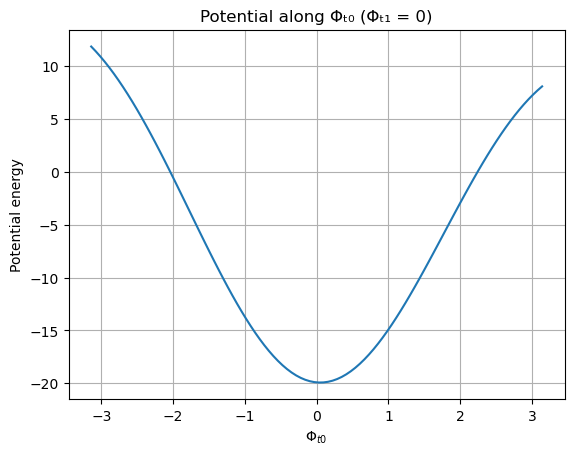

In [27]:

# 测试：固定 q = 0，扫描 phi0 和 phi1
import numpy as np
import matplotlib.pyplot as plt

phi0 = np.linspace(-np.pi, np.pi, 100)
phi1 = 0.0  # 固定 phi1 为 0
q0 = 0.0
q1 = 0.0

# 计算势能部分（固定动量为0）
# 注意：phi_vals 和 q_vals 需要按顺序传入列表/元组
potential = H_numeric([phi0, phi1], [q0, q1])  # 自动广播

plt.plot(phi0, potential)
plt.xlabel(r'$\Phi_{t0}$')
plt.ylabel('Potential energy')
plt.title('Potential along Φₜ₀ (Φₜ₁ = 0)')
plt.grid()
plt.show()

### NumPy 加速演示：复杂电路的 Hamiltonian 计算性能对比

构建一个更复杂的超导电路（5 节点、10 个元件、含互感），分别用**纯数值参数**（自动走 NumPy 路径）和**符号参数**（走 SymPy 路径）计算哈密顿量，对比耗时。

电路拓扑：
```
     C1      L1       C3
 0 ──┤├── 1 ──⌇── 2 ──┤├── 3
 │         │         │         │
 JJ1       C2        JJ3       C4
 │         │         │         │
 └─── 4 ───┘─── L2 ──┘─── JJ2 ┘
          （L1 与 L2 互感耦合）
```

In [ ]:
# 23. 构建复杂电路 —— 纯数值参数 (自动走 NumPy 路径)
import time

circuit_num = Circuit()

# 元件 (全部使用数值)
circuit_num.add_component(0, 1, 'C',  1.2)     # C1
circuit_num.add_component(1, 2, 'L',  0.8)     # L1
circuit_num.add_component(2, 3, 'C',  1.5)     # C3
circuit_num.add_component(0, 4, 'JJ', 12.0)    # JJ1
circuit_num.add_component(1, 4, 'C',  0.9)     # C2
circuit_num.add_component(2, 4, 'L',  0.6)     # L2
circuit_num.add_component(3, 4, 'JJ', 8.0)     # JJ2
circuit_num.add_component(2, 4, 'JJ', 10.0)    # JJ3
circuit_num.add_component(3, 4, 'C',  1.1)     # C4
circuit_num.add_component(0, 3, 'C',  0.7)     # C5 (额外跨接电容)

# 互感耦合: L1 与 L2
circuit_num.add_mutual(1, 5, 0.15)  # comp_id 1 (L1) 与 comp_id 5 (L2)

# 设置外磁通 (直接指定模式)
for i in range(circuit_num.num_loops):
    circuit_num.set_external_flux(i, 0.1 * (i + 1))

print(f"节点数: {len(circuit_num.nodes)}")
print(f"元件数: {len(circuit_num.components)}")
print(f"基本回路数: {circuit_num.num_loops}")
circuit_num.print_edges()

In [ ]:
# 24. 构建相同拓扑的电路 —— 符号参数 (强制走 SymPy 路径)
circuit_sym = Circuit()

# 相同拓扑, 但使用符号参数
circuit_sym.add_component(0, 1, 'C',  'C1')
circuit_sym.add_component(1, 2, 'L',  'L1')
circuit_sym.add_component(2, 3, 'C',  'C3')
circuit_sym.add_component(0, 4, 'JJ', 'EJ1')
circuit_sym.add_component(1, 4, 'C',  'C2')
circuit_sym.add_component(2, 4, 'L',  'L2')
circuit_sym.add_component(3, 4, 'JJ', 'EJ2')
circuit_sym.add_component(2, 4, 'JJ', 'EJ3')
circuit_sym.add_component(3, 4, 'C',  'C4')
circuit_sym.add_component(0, 3, 'C',  'C5')

# 互感
circuit_sym.add_mutual(1, 5, 'M12')

# 外磁通
for i in range(circuit_sym.num_loops):
    circuit_sym.set_external_flux(i, sp.Symbol(f'Phi_ext{i}'))

print("符号电路构建完成")

In [ ]:
# 25. 性能对比: NumPy 路径 vs SymPy 路径

N_RUNS = 5  # 多次运行取平均, 排除首次编译/缓存的影响

# --- NumPy 路径计时 ---
times_numpy = []
for _ in range(N_RUNS):
    circuit_num._clear_cache()          # 清除缓存, 强制重新计算
    circuit_num._clear_flux_dependent_cache()
    # 重新设置磁通 (缓存已清除)
    for i in range(circuit_num.num_loops):
        circuit_num.set_external_flux(i, 0.1 * (i + 1))
    t0 = time.perf_counter()
    H_num, info_num = circuit_num.hamiltonian()
    times_numpy.append(time.perf_counter() - t0)

avg_numpy = sum(times_numpy) / N_RUNS

# --- SymPy 路径计时 ---
times_sympy = []
for _ in range(N_RUNS):
    circuit_sym._clear_cache()
    circuit_sym._clear_flux_dependent_cache()
    for i in range(circuit_sym.num_loops):
        circuit_sym.set_external_flux(i, sp.Symbol(f'Phi_ext{i}'))
    t0 = time.perf_counter()
    H_sym, info_sym = circuit_sym.hamiltonian()
    times_sympy.append(time.perf_counter() - t0)

avg_sympy = sum(times_sympy) / N_RUNS

print(f"NumPy 路径 (纯数值参数):  平均 {avg_numpy:.4f} s  (共 {N_RUNS} 次)")
print(f"SymPy 路径 (符号参数):    平均 {avg_sympy:.4f} s  (共 {N_RUNS} 次)")
print(f"加速比: {avg_sympy / avg_numpy:.1f}x")

In [ ]:
# 26. 查看数值路径得到的哈密顿量
print("NumPy 路径哈密顿量:")
display(H_num)

In [ ]:
# 27. 查看符号路径得到的哈密顿量
print("SymPy 路径哈密顿量:")
display(H_sym)